In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [38]:
train_data = pd.read_csv('train.csv',encoding='latin1')
test_data = pd.read_csv('test.csv',encoding='latin1')
print(train_data.head())
print(test_data.head())

       textID  ... Density (P/Km²)
0  cb774db0d1  ...              60
1  549e992a42  ...             105
2  088c60f138  ...              18
3  9642c003ef  ...             164
4  358bd9e861  ...              26

[5 rows x 10 columns]
       textID  ... Density (P/Km²)
0  f87dea47db  ...            60.0
1  96d74cb729  ...           105.0
2  eee518ae67  ...            18.0
3  01082688c6  ...           164.0
4  33987a8ee5  ...            26.0

[5 rows x 9 columns]


In [48]:
nltk.download('punkt_ta')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [39]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())


textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64
textID              1281
text                1281
sentiment           1281
Time of Tweet       1281
Age of User         1281
Country             1281
Population -2020    1281
Land Area (Km²)     1281
Density (P/Km²)     1281
dtype: int64


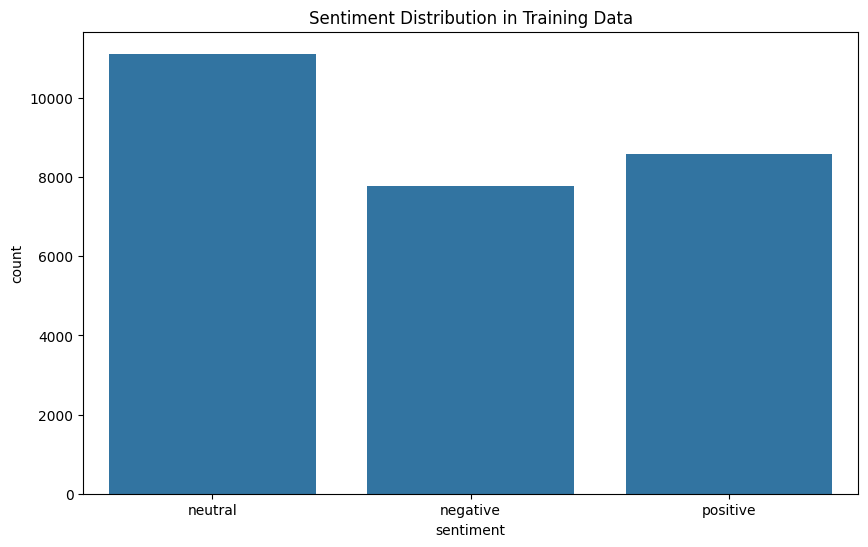

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=train_data)
plt.title('Sentiment Distribution in Training Data')
plt.show()

In [42]:
train_data['text'] = train_data['text'].astype(str)
test_data['text'] = test_data['text'].astype(str)

In [43]:
train_data.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [44]:
def clean_text(text):
  if pd.isna(text):
    return ""
  text = text.lower()
  text = re.sub(r'https?://\S+','',text)
  text = re.sub(r'<.*?>','',text)
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'#(\w+)', r'\1', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\d+', '', text)
  text = re.sub(r'\s+', ' ', text).strip()

  return text





In [50]:
def preprocess_text(text):
  if pd.isna(text):
    return ""
  text = clean_text(text)
  tokens = word_tokenize(text)
  stop_word = set(stopwords.words('english'))
  tokens = [token for token in tokens if token not in stop_word]
  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(token)for token in tokens]
  processed_text = ' '.join(tokens)

  return processed_text



In [51]:
print("Preprocessing training data (this may take a few minutes)...")
train_data['processed_text'] = train_data['text'].apply(preprocess_text)

print("Preprocessing test data (this may take a few minutes)...")
test_data['processed_text'] = test_data['text'].apply(preprocess_text)

Preprocessing training data (this may take a few minutes)...
Preprocessing test data (this may take a few minutes)...


In [52]:
print("\nOriginal vs Processed Text Examples:")
for i in range(3):
    print(f"Original: {train_data.iloc[i]['text']}")
    print(f"Processed: {train_data.iloc[i]['processed_text']}")
    print("---")


Original vs Processed Text Examples:
Original:  I`d have responded, if I were going
Processed: id responded going
---
Original:  Sooo SAD I will miss you here in San Diego!!!
Processed: sooo sad miss san diego
---
Original: my boss is bullying me...
Processed: bos bullying
---


In [ ]:
sentiment_mapping = {'negative':0,'neutral':2,'positive':4}
if train_data['sentiment'].dtype == 'object':
  train_data['sentiment_encoded'] = train_data['sentiment'].map(sentiment_mapping)
  test_data['sentiment_encoded'] = test_data['sentiment'].map(sentiment_mapping)
else:
  train_data['sentiment_encoded'] = train_data['sentiment']
  test_data['sentiment_encoded'] = test_data['sentiment']


In [63]:
test_data = test_data.dropna(subset=['text', 'sentiment'])
train_data = train_data.dropna(subset=['text', 'sentiment_encoded'])


In [64]:


X_train,X_val,y_train,y_val = train_test_split(
    train_data['processed_text'],
    train_data['sentiment_encoded'],
    test_size=0.2,
    random_state=42,
    stratify = train_data_for_split['sentiment_encoded']
)

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

In [69]:
print(X_train_vec.shape[0])
print(X_val_vec.shape[0])

15760
3940


In [70]:
ra = RandomForestClassifier(n_estimators=100, random_state=42)
ra.fit(X_train_vec, y_train)
y_pred = ra.predict(X_val_vec)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         2.0       0.81      0.82      0.82      2224
         4.0       0.76      0.76      0.76      1716

    accuracy                           0.79      3940
   macro avg       0.79      0.79      0.79      3940
weighted avg       0.79      0.79      0.79      3940



In [74]:
lr = LogisticRegression()
lr.fit(X_train_vec, y_train)
y_pred = lr.predict(X_val_vec)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         2.0       0.78      0.89      0.83      2224
         4.0       0.82      0.68      0.74      1716

    accuracy                           0.79      3940
   macro avg       0.80      0.78      0.79      3940
weighted avg       0.80      0.79      0.79      3940



In [72]:
count = CountVectorizer()
X_train_count = count.fit_transform(X_train)
X_val_count = count.transform(X_val)

In [73]:
lr = LogisticRegression()
lr.fit(X_train_count, y_train)
y_pred = lr.predict(X_val_count)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         2.0       0.80      0.87      0.83      2224
         4.0       0.80      0.72      0.76      1716

    accuracy                           0.80      3940
   macro avg       0.80      0.79      0.79      3940
weighted avg       0.80      0.80      0.80      3940



In [ ]:
filename = 'Randomforest_tfidf_model.pkl'
with open(filename , 'wb') as file:
  pickle.dump(ra, file)
print("model save successfully")